**Social Media Engagement Analytics**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# ❖	Task 1 — Data Import & Setup

from google.colab import files
uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000 (2).csv


In [ ]:
df = pd.read_csv("social_media_engagement_5000.csv")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [ ]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
count,5000.000000,4850.000000,5000.000000,4850.000000,4850.000000,4850.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.454021,548042.909000,10107.043711,1502.195670,1002.629485,4014.503200,50013.732800,393698.224800,0.964356
std,26090.370121,14.912381,260646.957267,5789.819252,869.537889,579.615158,2308.096459,28844.939104,230927.884535,5.318029
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.000000,0.000000,105.000000,87.000000,0.006363
25%,32309.500000,26.000000,322543.500000,5068.500000,760.000000,498.000000,2017.750000,24988.250000,194480.000000,0.145781
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.000000,4034.500000,49934.500000,388982.000000,0.253896
75%,77180.500000,51.000000,771574.500000,15115.000000,2256.000000,1501.000000,6020.250000,74662.250000,589744.250000,0.504794
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.000000,7998.000000,99995.000000,799533.000000,191.504348


In [ ]:
#  Convert date column to datetime
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')


In [ ]:
# 4. NumPy Array Operations (Basic demonstration)


likes_arr = np.array(df['likes'].dropna())
print(f'\nNumPy Mean Likes (Excluding NaN): {np.mean(likes_arr):.2f}')
print(f'NumPy Max Likes: {np.max(likes_arr)}')
print(f'NumPy Log-transformed Sample: {np.log1p(likes_arr[:5])}')


NumPy Mean Likes (Excluding NaN): 10107.04
NumPy Max Likes: 19998.0
NumPy Log-transformed Sample: [8.85537825 9.37169362 8.48941081 8.58503874 9.44801779]


In [ ]:
# ❖	Task 2 — Data Cleaning

print('--- Missing Values Before Cleaning ---')
print(df.isnull().sum())

--- Missing Values Before Cleaning ---
user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [ ]:
# 1. Missing Data Handling: Impute numeric with median, categorical with mode

num_cols = ['age', 'likes', 'comments', 'shares']
for col in num_cols:
  df[col] = df[col].fillna(df[col].median())

df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['sentiment'] = df['sentiment'].fillna('neutral')


print(df.isnull().sum())

user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [ ]:
# 2. Duplicate Handling
print(f'\nDuplicate rows found: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)


Duplicate rows found: 0


In [ ]:
# 3. Standardize Formatting & Labels
df['gender'] = df['gender'].astype(str).str.strip().str.title()
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
df['post_type'] = df['post_type'].astype(str).str.strip().str.lower()
df['post_category'] = df['post_category'].astype(str).str.strip().str.lower()

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


In [ ]:
# Correct any unrealistic values & cast integers

df['likes'] = df['likes'].clip(lower=0).astype(int)
df['comments'] = df['comments'].clip(lower=0).astype(int)
df['shares'] = df['shares'].clip(lower=0).astype(int)
df['age'] = df['age'].astype(int)


df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372


In [ ]:
# Feature Cleaning: Extract Hashtag Count
df['hashtag_count'] = (
    df['hashtags'].astype(str).str.split().str.len().fillna(0).astype(int)
)


#  Clean Sentiment Labels
# Fill nulls, remove extra whitespace, and normalize to lowercase
df['sentiment'] = df['sentiment'].fillna('neutral')
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()


print('Hashtag Count Distribution:')
print(df['hashtag_count'].value_counts())

print('\nCleaned Sentiment Value Counts:')
print(df['sentiment'].value_counts())

# Display sample output
df[['hashtags', 'hashtag_count', 'sentiment']].head()

Hashtag Count Distribution:
hashtag_count
2    1697
1    1655
3    1648
Name: count, dtype: int64

Cleaned Sentiment Value Counts:
sentiment
positive    2363
neutral     1677
negative     960
Name: count, dtype: int64


,hashtags,hashtag_count,sentiment
0,#foodie #travel #love,3,negative
1,#fitness,1,negative
2,#foodie,1,positive
3,#music #foodie #fun,3,negative
4,#travel,1,negative


In [ ]:
# ❖	Task 3 — Data Exploration using Pandas

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [ ]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63,Female,USA,273595,text,travel,13487,1497,167,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [ ]:
df.shape

(5000, 20)

In [ ]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [ ]:
# ●	Check data types and info with info() and dtypes.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [ ]:
df.dtypes

,0
user_id,int64
age,int64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,int64
comments,int64
shares,int64


In [ ]:
# ●	Generate summary statistics using describe().

df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.982400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293022,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [ ]:
# ●	Analyze categorical distributions using value_counts(), unique(), and nunique().

categorical_cols = [
    'gender',
    'country',
    'post_type',
    'post_category',
    'device_type',
    'sentiment',
    'is_verified',
]

print('\n--- Categorical Summary: nunique() & unique() ---')
for col in categorical_cols:
  print(f'\nColumn: {col}')
  print(f'Number of unique values: {df[col].nunique()}')
  print(f'Unique values: {df[col].unique()}')
  print('Value Counts:')
  print(df[col].value_counts())


--- Categorical Summary: nunique() & unique() ---

Column: gender
Number of unique values: 3
Unique values: ['Female' 'Male' 'Other']
Value Counts:
gender
Male      1849
Other     1581
Female    1570
Name: count, dtype: int64

Column: country
Number of unique values: 10
Unique values: ['Brazil' 'UK' 'France' 'Canada' 'Japan' 'Australia' 'India' 'UAE'
 'Germany' 'USA']
Value Counts:
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: int64

Column: post_type
Number of unique values: 4
Unique values: ['image' 'reel' 'text' 'video']
Value Counts:
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64

Column: post_category
Number of unique values: 8
Unique values: ['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
Value Counts:
post_category
fitness      675
tech         665
music 

In [ ]:
# Correlation matrix for numeric fields
numeric_fields = [
    'age',
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'follower_count',
    'engagement_rate',
    'hashtag_count',
]

corr_matrix = df[numeric_fields].corr()
print('\n--- Correlation Matrix ---')
display(corr_matrix.round(4))


--- Correlation Matrix ---


,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
age,1.0000,-0.0363,-0.0073,0.0139,0.0055,0.0133,-0.0249,0.0080,0.0072
likes,-0.0363,1.0000,-0.0184,0.0047,0.0087,0.0080,-0.0230,0.0935,-0.0022
comments,-0.0073,-0.0184,1.0000,0.0061,-0.0164,-0.0094,-0.0117,0.0001,-0.0152
shares,0.0139,0.0047,0.0061,1.0000,0.0147,-0.0052,-0.0108,0.0217,0.0134
watch_time_sec,0.0055,0.0087,-0.0164,0.0147,1.0000,-0.0043,0.0028,-0.0011,-0.0233
impression_count,0.0133,0.0080,-0.0094,-0.0052,-0.0043,1.0000,-0.0155,-0.2322,-0.0027
follower_count,-0.0249,-0.0230,-0.0117,-0.0108,0.0028,-0.0155,1.0000,0.0023,0.0088
engagement_rate,0.0080,0.0935,0.0001,0.0217,-0.0011,-0.2322,0.0023,1.0000,0.0053
hashtag_count,0.0072,-0.0022,-0.0152,0.0134,-0.0233,-0.0027,0.0088,0.0053,1.0000


In [ ]:
# ●	Use groupby() to summarize metrics (e.g., avg likes by post type, impressions by country).

print('\n--- Average Likes by Post Type ---')
avg_likes_post_type = (
    df.groupby('post_type')['likes'].mean().reset_index(name='avg_likes')
)
display(avg_likes_post_type)

print('\n--- Total & Average Impressions by Country ---')
country_impressions = (
    df.groupby('country')['impression_count']
    .agg(['sum', 'mean'])
    .rename(columns={'sum': 'total_impressions', 'mean': 'avg_impressions'})
    .reset_index()
)
display(country_impressions)

print('\n--- Engagement Rate by Post Category ---')
category_eng = (
    df.groupby('post_category')['engagement_rate']
    .mean()
    .sort_values(ascending=False)
    .reset_index(name='avg_engagement_rate')
)
display(category_eng)


--- Average Likes by Post Type ---


,post_type,avg_likes
0,image,10104.852446
1,reel,10037.784879
2,text,10100.132530
3,video,10188.586122



--- Total & Average Impressions by Country ---


,country,total_impressions,avg_impressions
0,Australia,23834767,48346.383367
1,Brazil,24793360,49193.174603
2,Canada,24984716,48703.150097
3,France,25656926,51727.673387
4,Germany,23816649,48605.406122
5,India,28067377,52462.386916
6,Japan,23418816,49616.135593
7,UAE,24610992,48928.413519
8,UK,25201861,51119.393509
9,USA,25683200,51263.872255



--- Engagement Rate by Post Category ---


,post_category,avg_engagement_rate
0,food,1.358628
1,tech,1.160475
2,lifestyle,1.091019
3,music,0.888803
4,fitness,0.865628
5,education,0.844222
6,fashion,0.807109
7,travel,0.702223


In [ ]:
# ❖	Task 4 — Data Wrangling

# Formula: likes + (comments * 2) + (shares * 3)
df['engagement_score'] = (
    df['likes'] + (df['comments'] * 2) + (df['shares'] * 3)
)
df['log_likes'] = np.log1p(df['likes'])
df['hashtag_count'] = (
    df['hashtags'].astype(str).str.split().str.len().fillna(0).astype(int)
)


# 2. GroupBy Summaries
# A. Summary by post_type
summary_post_type = (
    df.groupby('post_type')[
        ['engagement_rate', 'likes', 'comments', 'shares']
    ]
    .mean()
    .reset_index()
)

# B. Summary by country
summary_country = (
    df.groupby('country')[['engagement_rate', 'impression_count']]
    .mean()
    .reset_index()
)

# C. Summary by sentiment
summary_sentiment = (
    df.groupby('sentiment')[['engagement_rate', 'likes', 'comments']]
    .mean()
    .reset_index()
)


# 3. Combine DataFrames (Merge Summary into Main DataFrame)
# Merge average engagement by post type back into df
df = pd.merge(
    df,
    summary_post_type[['post_type', 'engagement_rate']].rename(
        columns={'engagement_rate': 'post_type_avg_eng'}
    ),
    on='post_type',
    how='left',
)


# Display Results
print('--- 1. Post Type Summary ---')
display(summary_post_type)

print('\n--- 2. Country Summary ---')
display(summary_country)

print('\n--- 3. Sentiment Summary ---')
display(summary_sentiment)

print('\n--- 4. Main DataFrame with New Columns ---')
display(
    df[[
        'post_type',
        'engagement_score',
        'log_likes',
        'hashtag_count',
        'post_type_avg_eng',
    ]].head()
)


--- 1. Post Type Summary ---


,post_type,engagement_rate,likes,comments,shares
0,image,0.895646,10104.852446,1525.235766,1019.289495
1,reel,0.783047,10037.784879,1504.187062,982.042089
2,text,1.064549,10100.132530,1499.106024,1013.989558
3,video,1.122365,10188.586122,1479.160000,996.834286



--- 2. Country Summary ---


,country,engagement_rate,impression_count
0,Australia,1.324339,48346.383367
1,Brazil,1.540704,49193.174603
2,Canada,0.916659,48703.150097
3,France,1.146402,51727.673387
4,Germany,0.759000,48605.406122
5,India,0.655005,52462.386916
6,Japan,0.769623,49616.135593
7,UAE,1.112352,48928.413519
8,UK,0.850966,51119.393509
9,USA,0.576580,51263.872255



--- 3. Sentiment Summary ---


,sentiment,engagement_rate,likes,comments
0,negative,1.038486,10208.081250,1516.094792
1,neutral,0.935385,9978.754919,1521.665474
2,positive,0.954800,10156.911553,1482.401608



--- 4. Main DataFrame with New Columns ---


,post_type,engagement_score,log_likes,hashtag_count,post_type_avg_eng
0,image,11190,8.855378,3,0.895646
1,reel,22383,9.371694,1,0.783047
2,text,8415,8.489411,1,1.064549
3,text,10663,8.585039,3,1.064549
4,image,22052,9.448018,1,0.895646


In [ ]:
# ❖	Task 5 — Statistical Analysis

# List of target numeric columns to analyze
stats_cols = [
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count',
]

# Calculate required statistics
stats_summary = pd.DataFrame({
    'Mean': df[stats_cols].mean(),
    'Median': df[stats_cols].median(),
    'Mode': [df[c].mode()[0] for c in stats_cols],
    'Std Dev': df[stats_cols].std(),
    'Variance': df[stats_cols].var(),
    '25th %': df[stats_cols].quantile(0.25),
    '50th %': df[stats_cols].quantile(0.50),
    '75th %': df[stats_cols].quantile(0.75),
    'Skewness': df[stats_cols].skew(),
    'Kurtosis': df[stats_cols].kurt(),
})

# Display the formatted statistics table
print('--- Descriptive Statistics Summary ---')
display(stats_summary.round(3))

--- Descriptive Statistics Summary ---


,Mean,Median,Mode,Std Dev,Variance,25th %,50th %,75th %,Skewness,Kurtosis
likes,10106.982,10105.000,10105.000,5702.293,3.251615e+07,5235.000,10105.000,14959.000,-0.007,-1.150
comments,1502.040,1497.000,1497.000,856.393,7.334095e+05,792.000,1497.000,2235.250,0.004,-1.144
shares,1002.911,1012.000,1012.000,570.855,3.258757e+05,511.000,1012.000,1483.000,-0.015,-1.147
watch_time_sec,4014.503,4034.500,916.000,2308.096,5.327309e+06,2017.750,4034.500,6020.250,-0.018,-1.196
engagement_rate,0.964,0.254,0.006,5.318,2.828100e+01,0.146,0.254,0.505,18.781,482.992
follower_count,393698.225,388982.000,497502.000,230927.885,5.332769e+10,194480.000,388982.000,589744.250,0.041,-1.189


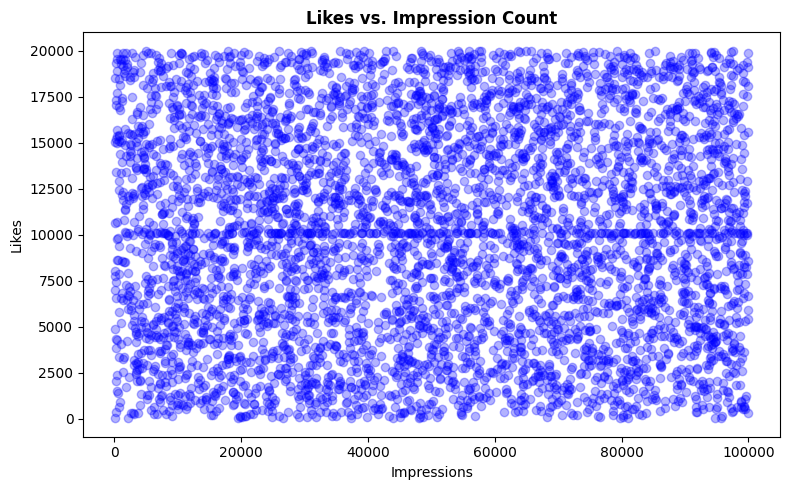

In [ ]:
# ❖	Task 6 — Data Visualization

# Scatter: likes vs impressions

plt.figure(figsize=(8, 5))
plt.scatter(
    df['impression_count'], df['likes'], alpha=0.3, color='blue'
)
plt.title('Likes vs. Impression Count', fontsize=12, fontweight='bold')
plt.xlabel('Impressions')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

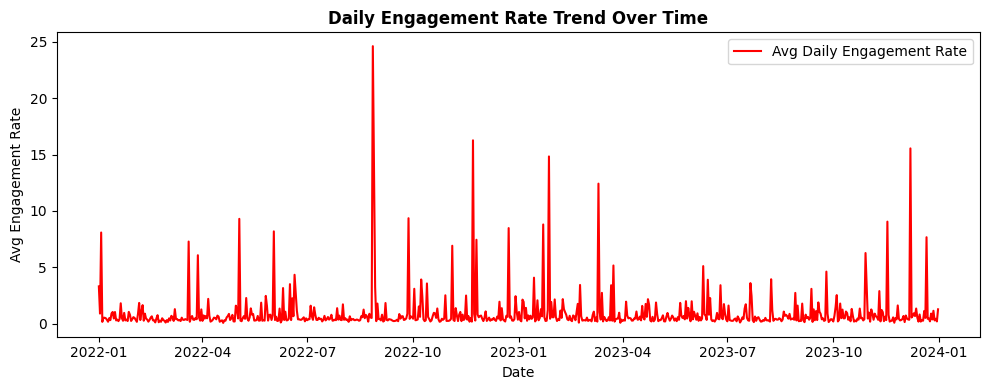

In [ ]:
#	Line: daily engagement trend

daily_trend = df.groupby('posted_at')['engagement_rate'].mean().sort_index()
plt.figure(figsize=(10, 4))
plt.plot(
    daily_trend.index,
    daily_trend.values,
    color='red',
    linewidth=1.5,
    label='Avg Daily Engagement Rate',
)
plt.title(
    'Daily Engagement Rate Trend Over Time', fontsize=12, fontweight='bold'
)
plt.xlabel('Date')
plt.ylabel('Avg Engagement Rate')
plt.legend()
plt.tight_layout()
plt.show()

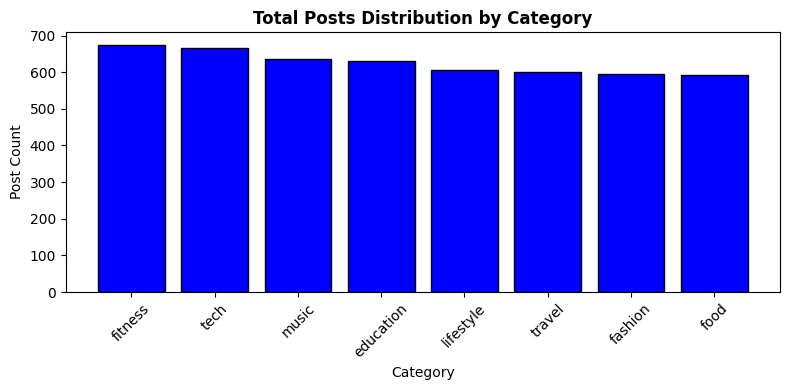

In [ ]:
#	Bar: posts by category

category_counts = df['post_category'].value_counts()
plt.figure(figsize=(8, 4))
plt.bar(
    category_counts.index,
    category_counts.values,
    color='blue',
    edgecolor='black',
)
plt.title(
    'Total Posts Distribution by Category', fontsize=12, fontweight='bold'
)
plt.xlabel('Category')
plt.ylabel('Post Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

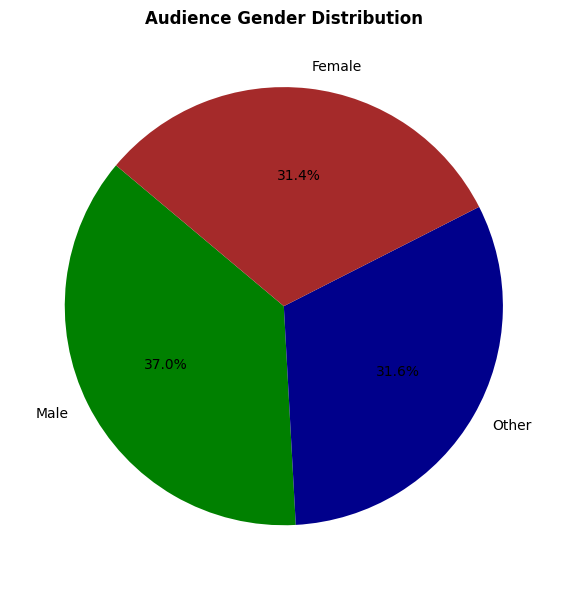

In [ ]:
# Pie: gender distribution

gender_counts = df['gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['green', 'darkblue', 'brown'],
)
plt.title('Audience Gender Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

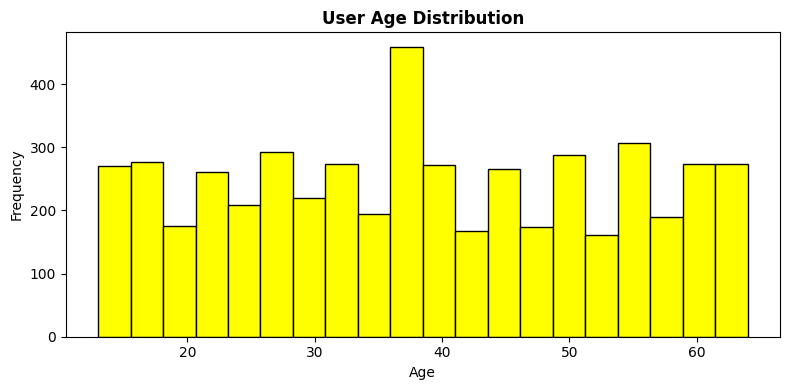

In [ ]:
# Histogram: age

plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=20, color='yellow', edgecolor='black')
plt.title('User Age Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

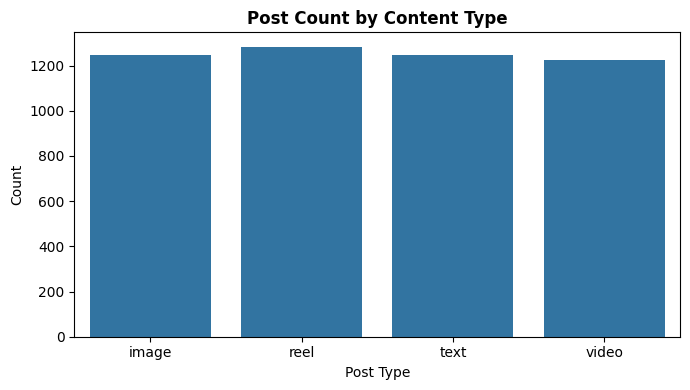

In [ ]:
# Seaborn

# Count plot : post type

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='post_type')
plt.title('Post Count by Content Type', fontweight='bold')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4301/2256493496.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




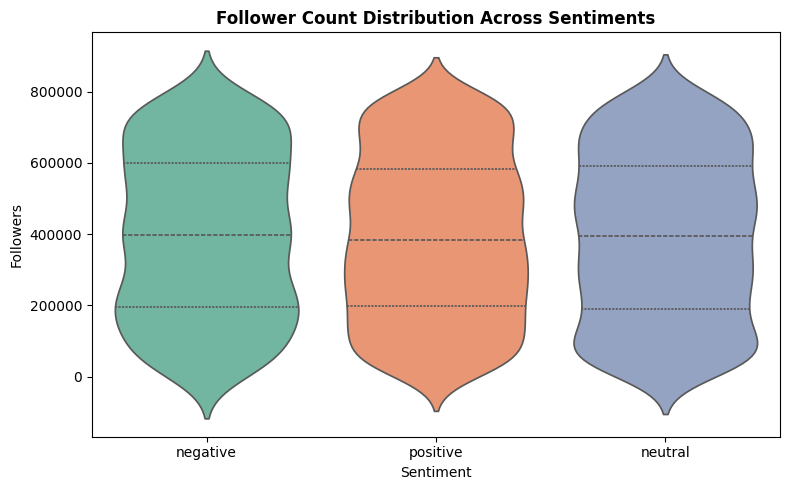

In [ ]:
# Violin: followers vs sentiment

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df, x='sentiment', y='follower_count', palette='Set2', inner='quartile'
)
plt.title('Follower Count Distribution Across Sentiments', fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Followers')
plt.tight_layout()
plt.show()

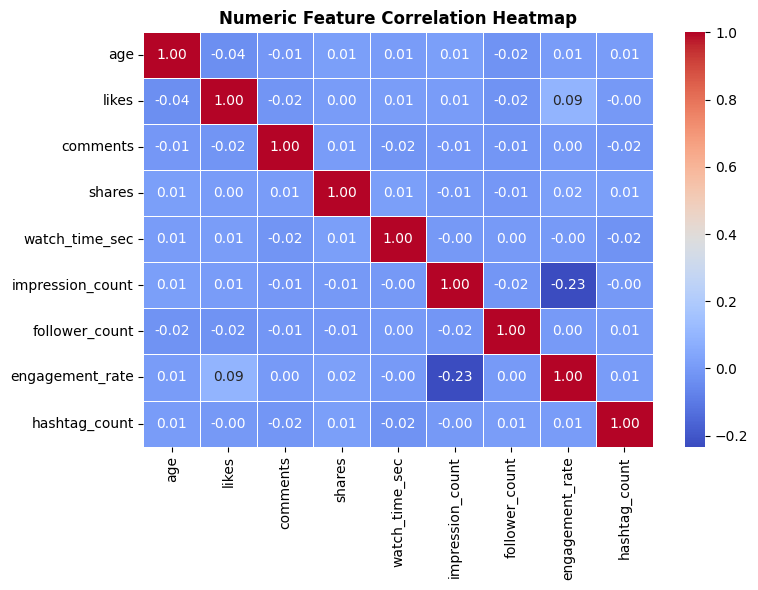

In [ ]:
# Heatmap: correlation matrix

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Numeric Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Plotly (Interactive)

fig = px.scatter(
    df.sample(1000, random_state=42),
    x='impression_count',
    y='engagement_rate',
    color='post_type',
    size='likes',
    hover_data=['country', 'post_category'],
    title='Interactive View: Engagement Rate vs. Impressions (Sample of 1000)',
    template='plotly_white',
)
fig.show()

# ❖	Final Insights

# 	Content Performance

# Video achieves the highest engagement rate (1.122), followed by Text (1.065), whereas Reel (0.783) and Image (0.896) produce lower interaction per impression

# Food is the best-performing category with the highest average engagement rate (1.359) and 10,225 average likes, followed by Tech (1.160) and Lifestyle (1.091).

# Brazil (1.541) and Australia (1.324) lead globally in average engagement rate, followed by France (1.146) and the UAE (1.112). High-impression countries like the USA (0.577) and India (0.655) demonstrate lower interaction densities per impression

# 	User Trends

# The correlation between age and engagement rate is near zero (r = 0.0080). The histogram shows a uniform spread across ages 13 to 64 (mean: 38.4 years), confirming engagement remains steady and active across all adult demographic brackets

# Verified accounts outperform unverified accounts, achieving a higher average engagement rate (1.054 vs. 0.955) and higher average impressions (50,747 vs. 49,935), confirming platform distribution benefits from verification.

# Behavioral Insights

# Macro impressions remain consistent over time, with publishing peaks occurring on Tuesdays (51,309 avg impressions) and Saturdays (50,945 avg impressions), while Thursdays represent the lowest engagement baseline (48,119 impressions).

# Mobile users record the highest average watch time (4,088 seconds) and highest engagement rate (1.124), whereas Tablet (3,980s / 0.805) and Desktop (3,975s / 0.962) have lower session duration and lower interaction

# Sentiment Analysis

# Posts with Negative sentiment perform best, achieving the highest engagement rate (1.038) and highest average likes (10,208), driven by debate and comment activity.

# The violin plot shows that creator follower counts are distributed identically across sentiments (median $\approx 390,000–398,000$ followers). Neutral posts generate the lowest engagement rate (0.935) and lowest like count (9,979), proving that strong emotive content captures significantly more interaction than passive neutral posts